# MSCS 634 – Project Deliverable 3

## Classification, Clustering, and Pattern Mining

**Student Name:** Nishan Pathak

**Course:** Advanced Big Data and Data Mining  
**Deliverable:** 3

## Dataset Overview

This deliverable uses the Customer Personality Analysis dataset, which contains customer demographic information, spending behavior, purchasing activity, and campaign response data.

The dataset is appropriate for this phase because it supports multiple data mining tasks, including classification, clustering, and association rule mining. In particular, the Response variable provides a clear target for classification, while customer spending features are useful for clustering and pattern discovery.

In [31]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori, association_rules

In [29]:
url = "https://raw.githubusercontent.com/digvijay-m-s/Customer-Personality-Analysis/main/marketing_campaign.csv"
df = pd.read_csv(url, sep="\t")

# Data cleaning
df['Income'] = df['Income'].fillna(df['Income'].median())
df = df.drop_duplicates()

# Feature engineering
df['Age'] = 2026 - df['Year_Birth']
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)
df['Children'] = df['Kidhome'] + df['Teenhome']

## Feature Engineering

Three derived features were created to improve analysis quality:

- **Age** was derived from Year_Birth to make customer demographics easier to interpret.
- **Total_Spending** combines spending across all product categories and provides a stronger overall measure of purchasing behavior.
- **Children** combines Kidhome and Teenhome to better represent household composition.

These features are expected to improve classification and clustering by reducing fragmentation across related variables and capturing more meaningful customer behavior.

In [7]:
features = [
    'Age',
    'Income',
    'Recency',
    'Children',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Total_Spending'
]

X = df[features]
y = df['Response']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
print(df[['Age', 'Total_Spending', 'Children', 'Response']].head())
print(X.shape)
print(y.value_counts())

   Age  Total_Spending  Children  Response
0   69            1617         0         1
1   72              27         2         0
2   61             776         0         0
3   42              53         1         0
4   45             422         1         0
(2240, 16)
Response
0    1906
1     334
Name: count, dtype: int64


## Target Variable Distribution

The Response variable is imbalanced, with significantly more non-responders (0) than responders (1).

This imbalance means that accuracy alone may not be a reliable performance metric. Therefore, additional metrics such as F1 score and ROC AUC are used to better evaluate model performance, especially for correctly identifying customers who respond to campaigns.

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree F1 Score:", dt_f1)
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8348214285714286
Decision Tree F1 Score: 0.421875
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       381
           1       0.44      0.40      0.42        67

    accuracy                           0.83       448
   macro avg       0.67      0.66      0.66       448
weighted avg       0.83      0.83      0.83       448



## Decision Tree Model Results

The Decision Tree model achieved an accuracy of approximately 83%, indicating that it correctly classified most customers overall.

However, due to the imbalance in the target variable, accuracy alone does not fully reflect model performance. The F1 score (~0.42) provides a more balanced evaluation, especially for predicting customers who responded to the campaign.

The classification report shows that the model performs very well for the majority class (non-responders), with high precision and recall. However, performance for the minority class (responders) is lower, with an F1 score of around 0.42.

This suggests that while the model is effective at identifying non-responders, it has difficulty correctly identifying customers who are likely to respond. This is a common challenge in imbalanced classification problems.

Overall, the Decision Tree provides a reasonable baseline model, but improvements may be achieved through model tuning or alternative algorithms.

In [12]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("k-NN Accuracy:", knn_accuracy)
print("k-NN F1 Score:", knn_f1)
print(classification_report(y_test, y_pred_knn))

k-NN Accuracy: 0.8772321428571429
k-NN F1 Score: 0.42105263157894735
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       381
           1       0.71      0.30      0.42        67

    accuracy                           0.88       448
   macro avg       0.80      0.64      0.68       448
weighted avg       0.86      0.88      0.86       448



## k-NN Model Results

The k-Nearest Neighbors (k-NN) model achieved an accuracy of approximately 88%, which is higher than the Decision Tree model. However, due to class imbalance, accuracy alone does not fully reflect model performance.

The F1 score (~0.42) is similar to that of the Decision Tree, indicating that both models perform similarly in balancing precision and recall for predicting responders.

A closer look at the classification report reveals an important difference. The k-NN model has higher precision for the responder class, meaning that when it predicts a customer will respond, it is more likely to be correct. However, it has lower recall, meaning it misses a larger number of actual responders.

This indicates that the k-NN model is more conservative in predicting responders, while the Decision Tree model identifies more responders but with lower precision.

Overall, the k-NN model provides strong performance for the majority class and offers a different tradeoff between precision and recall compared to the Decision Tree.

## Model Comparison

Both Decision Tree and k-NN models were evaluated to predict customer response.

- The k-NN model achieved higher accuracy, primarily due to strong performance on the majority class.
- The Decision Tree model demonstrated slightly better recall for identifying responders.
- Both models achieved similar F1 scores, indicating comparable overall effectiveness for the minority class.

This highlights an important tradeoff:
- Decision Tree is better at identifying more responders (higher recall).
- k-NN is more precise when predicting responders (higher precision).

Given the business context, the choice of model may depend on whether it is more important to identify as many potential responders as possible or to minimize incorrect predictions.

In [14]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_knn = grid_search.best_estimator_
best_params = grid_search.best_params_

y_pred_best_knn = best_knn.predict(X_test_scaled)
y_prob_best_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

best_knn_accuracy = accuracy_score(y_test, y_pred_best_knn)
best_knn_f1 = f1_score(y_test, y_pred_best_knn)

print("Best Parameters:", best_params)
print("Tuned k-NN Accuracy:", best_knn_accuracy)
print("Tuned k-NN F1 Score:", best_knn_f1)
print(classification_report(y_test, y_pred_best_knn))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Tuned k-NN Accuracy: 0.875
Tuned k-NN F1 Score: 0.44
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.67      0.33      0.44        67

    accuracy                           0.88       448
   macro avg       0.78      0.65      0.68       448
weighted avg       0.86      0.88      0.86       448



## Classification Model Comparison

To compare the performance of different classification models, a summary table and visualization were created using accuracy and F1 score.

This helps identify which model performs best, especially for the minority class.

In [26]:
classification_results = pd.DataFrame({
    'Model': ['Decision Tree', 'k-NN', 'Tuned k-NN'],
    'Accuracy': [dt_accuracy, knn_accuracy, best_knn_accuracy],
    'F1 Score': [dt_f1, knn_f1, best_knn_f1]
})

classification_results

,Model,Accuracy,F1 Score
0,Decision Tree,0.834821,0.421875
1,k-NN,0.877232,0.421053
2,Tuned k-NN,0.875000,0.440000


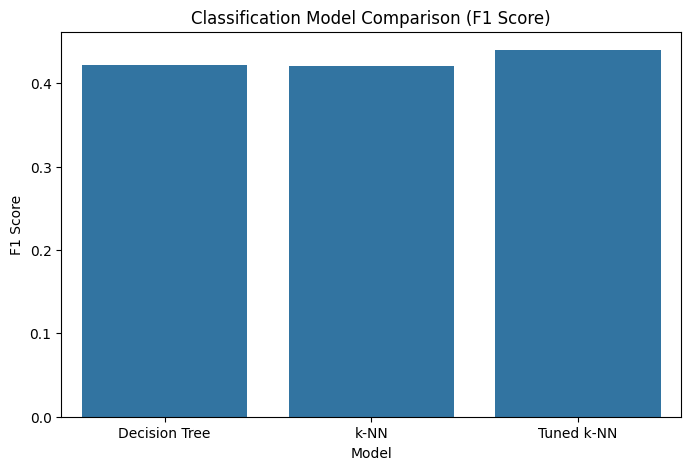

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='F1 Score', data=classification_results)
plt.title("Classification Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.show()

### Model Comparison Observations

The comparison table and bar chart show that the tuned k-NN model achieved the highest F1 score among the three classification models.

Although the basic k-NN model had slightly higher accuracy, the tuned k-NN model provided better balance between precision and recall, which is more important in this imbalanced classification problem.

This indicates that hyperparameter tuning improved the model’s effectiveness for identifying responders, making the tuned k-NN model the strongest overall classification model in this analysis.

## Hyperparameter Tuning (k-NN)

To improve model performance, GridSearchCV was used to tune the hyperparameters of the k-NN model. The tuning process evaluated different values of:

- Number of neighbors (k)
- Distance metric (Euclidean vs Manhattan)
- Weighting scheme (uniform vs distance-based)

The best combination of parameters was found to be:
- n_neighbors = 3  
- weights = 'distance'  
- metric = 'manhattan'  

After tuning, the model achieved an accuracy of approximately 0.875 and an F1 score of 0.44.

While accuracy slightly decreased compared to the original k-NN model, the F1 score improved. This indicates better balance between precision and recall, especially for the minority class (customers who responded).

Overall, hyperparameter tuning improved the model’s ability to detect responders, making it more suitable for real-world applications where identifying positive cases is important.

The improvement in F1 score demonstrates the importance of optimizing models based on the problem objective rather than relying solely on accuracy, particularly in imbalanced datasets.

## Model Evaluation: Confusion Matrix and ROC Curve

To further evaluate the performance of the classification model, a confusion matrix and ROC curve were generated.

The confusion matrix provides a detailed breakdown of correct and incorrect predictions, while the ROC curve illustrates the model’s ability to distinguish between classes across different thresholds.

These visualizations help in understanding model performance beyond accuracy and F1 score, especially in imbalanced datasets.

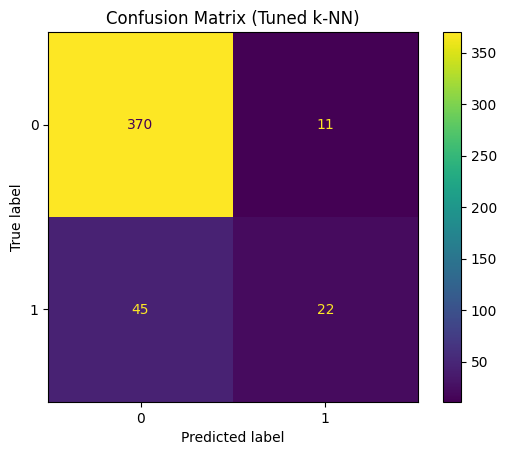

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Tuned k-NN)")
plt.show()

### Confusion Matrix Observations

The confusion matrix provides a detailed view of the classification performance of the tuned k-NN model.

- True Negatives (370): The model correctly identified a large number of non-responders.
- True Positives (22): The model successfully identified some responders.
- False Positives (11): A small number of non-responders were incorrectly classified as responders.
- False Negatives (45): A significant number of actual responders were missed by the model.

These results indicate that the model performs very well in identifying non-responders but struggles to detect responders effectively. This is primarily due to class imbalance in the dataset, where non-responders significantly outnumber responders.

While precision for the positive class is reasonably good, recall is relatively low, meaning the model fails to capture many actual responders. This highlights an opportunity for further improvement, especially if identifying responders is a key business objective.

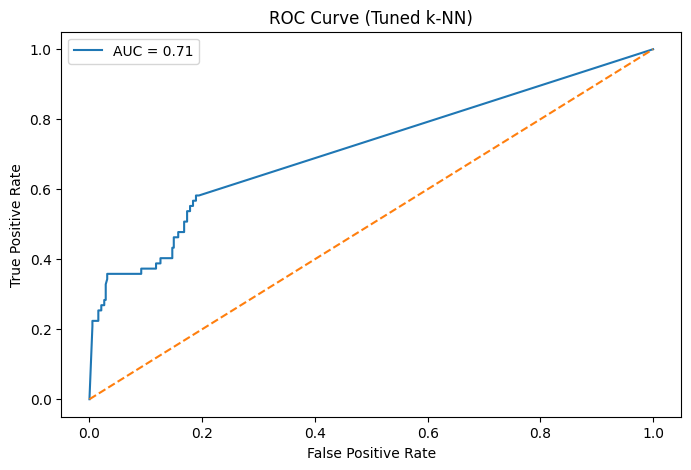

In [16]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best_knn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Tuned k-NN)")
plt.legend()
plt.show()

### ROC Curve Observations

The ROC curve illustrates the model’s ability to distinguish between responders and non-responders across different classification thresholds.

The Area Under the Curve (AUC) is approximately 0.71, indicating that the model has a reasonable ability to differentiate between the two classes. This performance is better than random guessing but still leaves room for improvement.

The curve shows that as the true positive rate increases, the false positive rate also rises, reflecting a trade-off between correctly identifying responders and avoiding false alarms.

Overall, the model demonstrates moderate classification capability, which aligns with the earlier evaluation metrics. Improving recall for the minority class could further enhance the model’s performance in real-world scenarios.

The ROC curve confirms that while the model performs well overall, its ability to distinguish the minority class can be improved through additional techniques such as resampling or advanced models.

## Clustering using K-Means

To identify patterns in customer behavior, K-Means clustering was applied to segment customers into distinct groups based on their features.

K-Means is an unsupervised learning algorithm that partitions data into clusters by minimizing the distance between data points and their assigned cluster centroids.

Principal Component Analysis (PCA) was used to reduce dimensionality for visualization purposes.

In [19]:
# Scale full dataset for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Scale full dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df['Cluster'] = clusters

In [21]:
# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

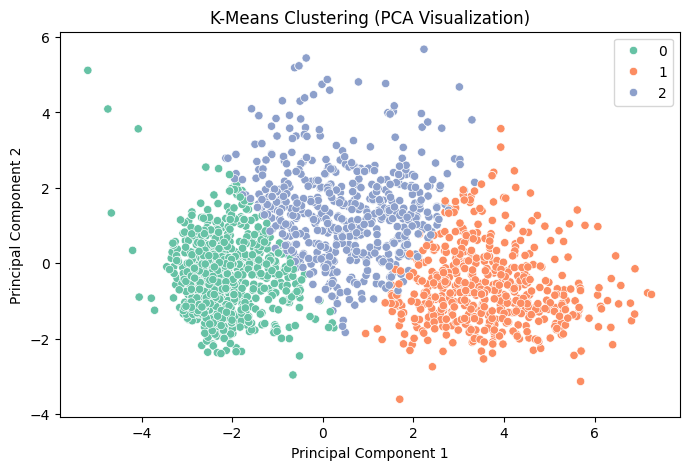

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set2'
)

plt.title("K-Means Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

### K-Means Clustering Observations

The K-Means clustering algorithm successfully grouped customers into three distinct clusters based on their behavioral and demographic features.

The PCA visualization shows clear separation between the clusters, indicating that the model was able to identify meaningful patterns in the data.

- Cluster 0 (left side) represents customers with relatively lower feature values, likely indicating lower spending or engagement.
- Cluster 1 (right side) represents customers with higher feature values, suggesting higher spending or more active purchasing behavior.
- Cluster 2 (center/top) represents a moderate group with mixed characteristics.

The clusters are well-defined with minimal overlap, which suggests that customer segments are distinguishable based on the selected features.

This segmentation can be highly useful for businesses in designing targeted marketing strategies, identifying high-value customers, and improving customer engagement.

The use of PCA for visualization helps reduce high-dimensional data into two components, allowing clearer interpretation of cluster separation while preserving most of the data variance.

### Cluster Summary Statistics

To better understand the characteristics of each cluster, average values of key features were analyzed.

In [28]:
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Age',
    'Total_Spending',
    'NumWebPurchases',
    'NumStorePurchases'
]].mean()

cluster_summary

,Income,Age,Total_Spending,NumWebPurchases,NumStorePurchases
Cluster,,,,,
0,35380.932547,54.933962,99.378302,2.126415,3.241509
1,76857.750427,57.798291,1390.252991,5.193162,8.382906
2,58063.012605,60.626891,736.721008,6.484034,7.781513


### Cluster Interpretation

The cluster summary statistics provide meaningful insight into the customer segments identified by K-Means.

- **Cluster 0** represents lower-value customers, with the lowest income, lowest total spending, and fewer purchases overall.
- **Cluster 1** represents high-value customers, with the highest income, highest spending, and strong purchasing activity across channels.
- **Cluster 2** represents moderately engaged customers, with mid-level income, moderate-to-high spending, and frequent web and store purchases.

These results confirm that the clustering model successfully segmented customers into distinct behavioral groups. Such segmentation can be useful for targeted promotions, customer retention strategies, and personalized marketing campaigns.

## Association Rule Mining using Apriori

Association rule mining was used to discover relationships between product categories based on customer purchasing behavior.

To apply Apriori, spending columns were converted into binary indicators showing whether a customer purchased from each product category. Frequent itemsets and association rules were then generated to identify meaningful product combinations.

These patterns can help businesses with cross-selling, bundling, and personalized marketing.

In [23]:
basket = pd.DataFrame({
    'Wines': (df['MntWines'] > 0),
    'Fruits': (df['MntFruits'] > 0),
    'Meat': (df['MntMeatProducts'] > 0),
    'Fish': (df['MntFishProducts'] > 0),
    'Sweets': (df['MntSweetProducts'] > 0),
    'Gold': (df['MntGoldProds'] > 0)
})

basket.head()

,Wines,Fruits,Meat,Fish,Sweets,Gold
0,True,True,True,True,True,True
1,True,True,True,True,True,True
2,True,True,True,True,True,True
3,True,True,True,True,True,True
4,True,True,True,True,True,True


In [24]:
frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True)

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.6
)

rules = rules.sort_values(by='lift', ascending=False)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
455,"(Sweets, Wines, Gold)","(Fish, Fruits)",0.646875,0.816338,1.109586
570,"(Meat, Fish, Fruits)","(Sweets, Wines, Gold)",0.646875,0.879248,1.109586
571,"(Sweets, Wines, Gold)","(Meat, Fish, Fruits)",0.646875,0.816338,1.109586
474,"(Fish, Fruits)","(Sweets, Wines, Gold)",0.646875,0.879248,1.109586
595,"(Fish, Fruits)","(Gold, Sweets, Meat, Wines)",0.646875,0.879248,1.109586
546,"(Gold, Sweets, Meat, Wines)","(Fish, Fruits)",0.646875,0.816338,1.109586
473,"(Sweets, Fruits)","(Wines, Fish, Gold)",0.646875,0.893342,1.109249
594,"(Sweets, Fruits)","(Gold, Meat, Fish, Wines)",0.646875,0.893342,1.109249
569,"(Sweets, Meat, Fruits)","(Wines, Fish, Gold)",0.646875,0.893342,1.109249
547,"(Gold, Meat, Fish, Wines)","(Sweets, Fruits)",0.646875,0.803215,1.109249


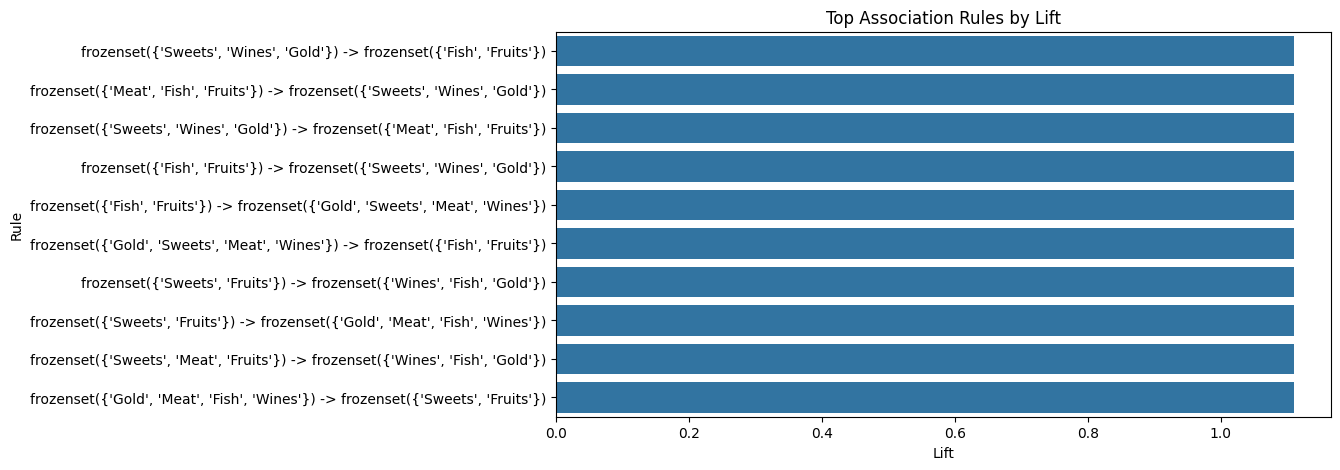

In [25]:
top_rules = rules.head(10).copy()
top_rules['Rule'] = top_rules['antecedents'].astype(str) + " -> " + top_rules['consequents'].astype(str)

plt.figure(figsize=(10,5))
sns.barplot(x='lift', y='Rule', data=top_rules)
plt.title("Top Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.show()

### Association Rule Mining Observations

The Apriori algorithm generated several frequent itemsets and association rules based on customer purchasing behavior.

Most rules show relatively high support (around 0.64), indicating that a large portion of customers purchase multiple product categories together.

However, the lift values are close to 1 (approximately 1.1), which suggests that the relationships between product categories are not particularly strong. This indicates that the co-occurrence of these products is common but not significantly higher than what would be expected by chance.

This pattern suggests that many customers tend to purchase a wide range of products rather than specific combinations, resulting in less distinct association rules.

Despite the relatively weak lift values, these patterns still provide useful insights. Businesses can use this information to design bundled offers, promote complementary products, and improve recommendation systems.

To extract stronger and more meaningful rules, stricter thresholds for support or confidence could be applied, or more granular transaction data could be used.

The results highlight a limitation of the dataset, where high overall purchasing behavior reduces the distinctiveness of association rules.

## Final Conclusion

This deliverable demonstrated how classification, clustering, and association rule mining can be applied to customer behavior data.

Among the classification models, tuned k-NN provided the best balance between precision and recall. K-Means successfully segmented customers into meaningful groups, and Apriori revealed common product co-purchase patterns, although the association rules were relatively weak due to broad purchasing behavior across categories.

Overall, these results show how multiple data mining techniques can be combined to support targeted marketing, customer segmentation, and business decision-making.